# E84 · Market structure analysis: who competes with whom?

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: the **margarine scanner panel** of Allenby & Rossi (1991; A.C. Nielsen, distributed with the R package bayesm): 4,470 purchases by 516 households of 10 products - Parkay, Blue Bonnet, Fleischmann's, Imperial, the store's house brand and a generic in sticks; Shedd's Spread, Parkay, Fleischmann's and the house brand in tubs - each purchase with the shelf price of all 10 products on that trip |
| **You will learn** | What **market structure** means and what it is used for (category management, positioning, **merger screening**) · the **brand-switching matrix** and switching lift, and why it mixes up three things · the pooled **multinomial logit** has *no* market structure by construction (**IIA**: diversion proportional to share) · the classic **nested-logit test** of competing hierarchies ("form first or brand first?") and why it is nearly powerless on pooled data · a hierarchical logit whose household brand preferences have a **low-rank factor structure** - a Bayesian **choice map** (Elrod 1988; Elrod & Keane 1995) · **rotation non-identifiability**: r_hat of 1.8 on the map with a perfectly good posterior, identified quantities, and **Procrustes alignment** of draws · **state dependence vs heterogeneity**: how "loyalty" shrinks as heterogeneity is modelled · held-out last purchases for choosing the number of dimensions · a **simulated-history posterior predictive check** · **diversion ratios**, **clout and vulnerability**, and a market tree with uncertainty · a Bayesian **upward-pricing-pressure (GUPPI) screen** for hypothetical mergers |

## The question

Which products compete with which? A brand manager asks it to know whose customers a price cut will
win. A retailer asks it to decide which products can share a shelf and which can be dropped. A
competition authority asks it before letting two firms merge: if the merged firm raises the price of
one product, how many of the lost customers will it recapture through the other? The answer is called
the **market structure** of a category, and it is usually drawn as a tree (submarkets within
submarkets) or a map (products close together compete hard).

The classic question for a category like margarine is whether the market is organised **by form**
(stick buyers compare sticks; tub buyers compare tubs) or **by brand** (a Parkay buyer compares Parkay
sticks with Parkay tubs), or by something else. Urban, Johnson & Hauser (1984), Grover & Srinivasan
(1987) and Kannan & Wright (1991) all tested such hierarchies. We will test them, see why the classic
test is weak, and build a model from which the structure can be *read off* instead of assumed.

The data are the scanner panel that Allenby & Rossi (1991) used to study **asymmetric switching**
between brands of different quality: 516 households in two US cities, their margarine purchases in
time order, and the price of every product on every shopping trip.

The decision we end with is an antitrust screen: **if two margarine brands merged, would the merged
firm have an incentive to raise prices?**

## The plan

1. The data: shares, prices and the switching matrix
2. The pooled logit and why it cannot see market structure
3. The classic test: nested logits for competing hierarchies
4. A choice map: household heterogeneity with a factor structure
5. How many dimensions, and is loyalty real?
6. A posterior predictive check on simulated purchase histories
7. Reading the market structure off the posterior
8. A merger screen

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
import xarray as xr
from matplotlib.patches import Ellipse
from scipy import special
from scipy.cluster import hierarchy

from pymc_challenges import data

RANDOM_SEED = 84
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # many fits: no sampler banner each
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")
warnings.filterwarnings("ignore", message="All-NaN slice")  # NaN diagonals of lift matrices
BLUE, ORANGE, AQUA, GREY, PURPLE, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PyTensor {pytensor.__version__}")


def q(x, probs=(0.05, 0.5, 0.95), axis=None):
    """Posterior quantiles, rounded for printing."""
    return np.round(np.quantile(x, probs, axis=axis), 2)

PyMC 6.3.2, ArviZ 1.3.0, PyTensor 3.3.2


---
# 1 · The data

## 1.1 · Purchases and prices

In [2]:
data.describe("margarine")
df = data.load("margarine")
demos = data.load("margarine_demos")
PRODUCTS = ["Pk_Stk", "BB_Stk", "Fl_Stk", "Hse_Stk", "Gen_Stk", "Imp_Stk",
            "SS_Tub", "Pk_Tub", "Fl_Tub", "Hse_Tub"]
NAMES = {"Pk": "Parkay", "BB": "Blue Bonnet", "Fl": "Fleischmann's", "Hse": "House brand",
         "Gen": "Generic", "Imp": "Imperial", "SS": "Shedd's Spread"}
J = len(PRODUCTS)
df["y"] = df["choice"].map({p: j for j, p in enumerate(PRODUCTS)})
df["hh"] = pd.factorize(df["hhid"])[0]
H = df["hh"].max() + 1
price = df[[f"price_{p}" for p in PRODUCTS]].to_numpy()
print(f"{len(df):,} purchases by {H} households; purchases per household: "
      f"median {df.groupby('hh').size().median():.0f}, range "
      f"{df.groupby('hh').size().min()}-{df.groupby('hh').size().max()}")
df.head()

margarine: 4,470 margarine purchases by 516 households, in time order within household (no dates): hhid, trip (1, 2, ... within household), choice (one of 10 products: Pk = Parkay, BB = Blue Bonnet, Fl = Fleischmann's, Hse = the store's house brand, Gen = generic, Imp = Imperial, SS = Shedd's Spread; _Stk = sticks, _Tub = tub), and price_<product>: the shelf price (US$ per pound) of every product on that shopping trip.
  source: Allenby & Rossi (1991), 'Quality perceptions and asymmetric switching between brands', Marketing Science 10:185-205: an A.C. Nielsen scanner panel, distributed as `margarine` in the R package bayesm (Rossi; GPL >= 2; the URL is its CRAN source tarball). CONVERTED from .rda by tools/build_e84_margarine.py - keep the cached file.
  url:    https://cran.r-project.org/src/contrib/Archive/bayesm/bayesm_3.1-6.tar.gz
4,470 purchases by 516 households; purchases per household: median 7, range 1-43


,hhid,trip,choice,price_Pk_Stk,price_BB_Stk,price_Fl_Stk,price_Hse_Stk,price_Gen_Stk,price_Imp_Stk,price_SS_Tub,price_Pk_Tub,price_Fl_Tub,price_Hse_Tub,y,hh
0,2100016,1,Pk_Stk,0.66,0.67,1.09,0.57,0.36,0.93,0.85,1.09,1.19,0.33,0,0
1,2100016,2,Pk_Stk,0.63,0.67,0.99,0.57,0.36,1.03,0.85,1.09,1.19,0.37,0,0
2,2100016,3,Pk_Stk,0.29,0.50,0.99,0.57,0.36,0.69,0.79,1.09,1.19,0.59,0,0
3,2100016,4,Pk_Stk,0.62,0.61,0.99,0.57,0.36,0.75,0.85,1.09,1.19,0.59,0,0
4,2100016,5,Pk_Stk,0.50,0.58,0.99,0.45,0.33,0.72,0.85,1.07,1.19,0.59,0,0


''

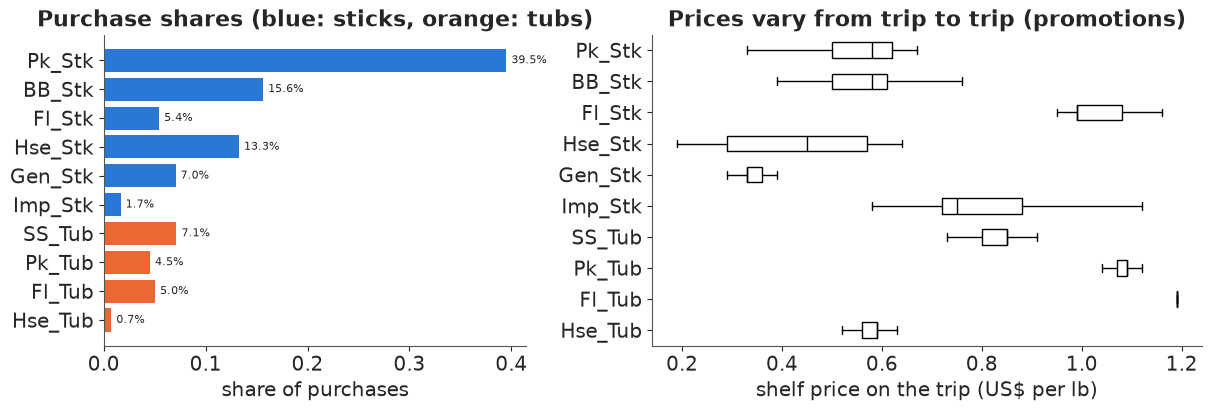

In [3]:
share = df["choice"].value_counts(normalize=True).reindex(PRODUCTS).to_numpy()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4), width_ratios=[1, 1.3])
col = [BLUE if p.endswith("Stk") else ORANGE for p in PRODUCTS]
a1.barh(PRODUCTS[::-1], share[::-1], color=col[::-1])
for j, s in enumerate(share[::-1]):
    a1.text(s + 0.005, j, f"{s:.1%}", va="center", fontsize=8)
a1.set_xlabel("share of purchases")
a1.set_title("Purchase shares (blue: sticks, orange: tubs)")
a2.boxplot(price[:, ::-1], orientation="horizontal", tick_labels=PRODUCTS[::-1], showfliers=False,
           medianprops=dict(color="k"))
a2.set_xlabel("shelf price on the trip (US$ per lb)")
a2.set_title("Prices vary from trip to trip (promotions)")
;

Parkay sticks take 40% of purchases; the house brand's tub less than 1%. Prices vary within each
product mostly through temporary price cuts, and **that variation identifies price sensitivity**:
the same household facing different relative prices on different trips. The spread differs a lot by
product - Parkay and Blue Bonnet sticks are promoted often, Fleischmann's tub almost never - which
will limit what we can learn about the tubs. The premium products (Fleischmann's, Imperial, the
national-brand tubs) cost two to three times as much per pound as the house brand and generic.

## 1.2 · The switching matrix

The oldest tool of market structure analysis is the **brand-switching matrix**: count, for
consecutive purchases of the same household, how often a purchase of product $k$ is followed by a
purchase of product $j$. Two products that shoppers switch between often are, the argument goes, in
the same submarket.

Raw counts mostly reflect size (everyone switches *to* Parkay because everyone buys Parkay), so we
compare each off-diagonal count with what it would be if a switcher leaving $k$ picked the next
product in proportion to overall shares, $s_j / (1 - s_k)$. The ratio is the **switching lift**:
above 1, $k$ and $j$ exchange more buyers than their sizes predict.

repeat purchases (same product as last time): 48.7% of 3,954 consecutive pairs


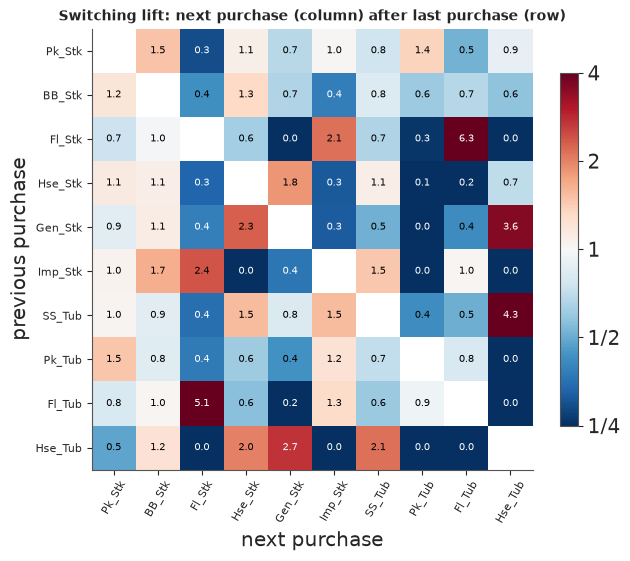

In [4]:
df["prev"] = df.groupby("hh")["y"].shift()
pairs = df.dropna(subset="prev")
sw = pd.crosstab(pairs["prev"].astype(int), pairs["y"]).reindex(index=range(J), columns=range(J),
                                                                  fill_value=0).to_numpy()
print(f"repeat purchases (same product as last time): {np.trace(sw) / sw.sum():.1%} of "
      f"{sw.sum():,} consecutive pairs")


def switching_lift(sw, share):
    off = sw.astype(float).copy()
    np.fill_diagonal(off, 0)
    expected = off.sum(1, keepdims=True) * share[None, :] / (1 - share[:, None])
    lift = off / expected
    np.fill_diagonal(lift, np.nan)
    return lift


def heat(ax, M, title, vmax=4, fmt="{:.1f}", counts=None):
    """Lift matrix on a log colour scale centred at 1 (rows: from; columns: to)."""
    im = ax.imshow(np.log2(np.clip(M, 1 / vmax, vmax)), cmap="RdBu_r", vmin=-np.log2(vmax),
                   vmax=np.log2(vmax))
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            if i != j and np.isfinite(M[i, j]):
                ax.text(j, i, fmt.format(M[i, j]), ha="center", va="center", fontsize=7,
                        color="w" if abs(np.log2(max(M[i, j], 1e-3))) > 1.3 else "k")
    ax.set_xticks(range(J), PRODUCTS, rotation=60, fontsize=8)
    ax.set_yticks(range(J), PRODUCTS, fontsize=8)
    ax.set_title(title, fontsize=10)
    return im


lift_raw = switching_lift(sw, share)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = heat(ax, lift_raw, "Switching lift: next purchase (column) after last purchase (row)")
cb = fig.colorbar(im, ax=ax, shrink=0.8, ticks=np.log2([0.25, 0.5, 1, 2, 4]))
cb.ax.set_yticklabels(["1/4", "1/2", "1", "2", "4"])
ax.set_xlabel("next purchase")
ax.set_ylabel("previous purchase");

About half of all purchases repeat the previous one, and the switching that remains is far from
proportional to shares. Blocks appear: **Fleischmann's stick and tub** swap buyers at five to six
times the proportional rate; the **house brand, the generic and Shedd's Spread** form a cheap
cluster; **Parkay stick, Blue Bonnet and Parkay tub** trade among themselves. Stick-versus-tub does
not look like the organising principle.

But a switching matrix mixes three different things, and the market-structure argument needs only
one of them:

1. **Heterogeneity.** Different households like different products. A household that likes both
   Fleischmann's products alternates between them; aggregate switching then *looks* like
   substitution, and it is - but only for that kind of household.
2. **Prices.** Promotions move buyers around; switching between two heavily promoted products is
   partly a record of the promotion calendar.
3. **State dependence.** Buying a product may itself make the next purchase of it more likely
   (habit, learning, or just remembering where it is on the shelf). This inflates the diagonal and
   is a *dynamic* effect, not a statement about substitution.

And small cells are noisy: the house brand's tub was bought 33 times in all, so its row and
column rest on a handful of switches. We need a model that separates the three and says how sure
it is.

---
# 2 · The pooled logit

## 2.1 · Setup: training data and a held-out last purchase

We model each purchase as a choice among the 10 products (a household's first purchase is used
only as the "previous purchase" of the second, because we will include state dependence). To
compare models on data they have not seen, the **last purchase of every household with at least
three** is held out; everything is fitted to the rest.

The utility of product $j$ for household $h$ on trip $t$ is

$$U_{htj} = \alpha_j + \beta\, p_{tj} + \gamma\, [\,j = \text{previous purchase}\,] + \varepsilon_{htj},$$

with Gumbel errors, so choice probabilities are a softmax (see E68 for the derivation). Parkay
sticks are the reference ($\alpha_1 = 0$). The price prior Normal(-3, 2) per dollar is wide: a
10-cent price cut changes the odds of purchase by somewhere between -10% and +100%.

In [5]:
df["T"] = df.groupby("hh")["trip"].transform("max")
fit_rows = df[df["trip"] >= 2].copy()
fit_rows["test"] = (fit_rows["trip"] == fit_rows["T"]) & (fit_rows["T"] >= 3)
train, test = fit_rows[~fit_rows["test"]], fit_rows[fit_rows["test"]]


def arrays(d):
    return dict(X=d[[f"price_{p}" for p in PRODUCTS]].to_numpy(),
                last=np.eye(J)[d["prev"].astype(int).to_numpy()],
                y=d["y"].to_numpy(), hh=d["hh"].to_numpy())


tr, te = arrays(train), arrays(test)
print(f"training purchases {len(train):,}; held-out last purchases {len(test)}")
coords = {"product": PRODUCTS, "alt": PRODUCTS[1:]}


def logit_model(lag):
    with pm.Model(coords=coords) as m:
        a = pm.Normal("alpha", 0, 2, dims="alt")
        alpha = pt.concatenate([pt.zeros(1), a])
        beta = pm.Normal("beta", -3, 2)
        V = alpha + beta * tr["X"]
        if lag:
            V = V + pm.Normal("gamma", 0, 2) * tr["last"]
        pm.Categorical("y", logit_p=V, observed=tr["y"])
    return m


def fit(model, var_names=None):
    t0 = time.time()
    with model:
        idata = pm.sample(random_seed=RANDOM_SEED, var_names=var_names)
    ss = idata.sample_stats
    print(f"sampled in {time.time() - t0:.0f} s ({idata.posterior.attrs.get('tuning_steps')} warm-up "
          f"steps, nutpie); divergences {int(ss['diverging'].sum())}; max tree depth "
          f"{int(ss['depth'].max())}")
    return idata


idata_logit = fit(logit_model(lag=False))
idata_logit_lag = fit(logit_model(lag=True))
az.summary(idata_logit_lag, var_names=["alpha", "beta", "gamma"], round_to=2)

training purchases 3,498; held-out last purchases 456


sampled in 5 s (400 warm-up steps, nutpie); divergences 0; max tree depth 4


sampled in 3 s (400 warm-up steps, nutpie); divergences 0; max tree depth 4


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha[BB_Stk],-0.64,0.06,-0.74,-0.54,4941.04,3548.34,1.00,0.00,0.0
alpha[Fl_Stk],2.22,0.13,2.01,2.44,928.53,1290.97,1.00,0.00,0.0
alpha[Hse_Stk],-1.36,0.07,-1.46,-1.25,3708.89,3128.64,1.00,0.00,0.0
alpha[Gen_Stk],-2.56,0.08,-2.70,-2.43,2474.97,2867.83,1.00,0.00,0.0
alpha[Imp_Stk],-0.58,0.15,-0.82,-0.35,3422.88,2870.53,1.00,0.00,0.0
alpha[SS_Tub],0.88,0.10,0.72,1.04,1313.02,1695.48,1.00,0.00,0.0
alpha[Pk_Tub],2.51,0.15,2.28,2.75,927.53,1315.30,1.00,0.00,0.0
alpha[Fl_Tub],3.45,0.17,3.19,3.72,827.64,1234.27,1.01,0.01,0.0
alpha[Hse_Tub],-3.17,0.21,-3.51,-2.85,6261.90,3073.50,1.00,0.00,0.0
beta,-7.45,0.21,-7.80,-7.11,777.90,1106.92,1.01,0.01,0.0


Clean fits in seconds. Price matters (about -7 per dollar per pound), and the pooled model says
buying a product last time multiplies the odds of buying it again by $e^{1.8} \approx 6$. Hold
that number; section 5 takes it apart.

## 2.2 · The logit has no market structure

Market structure is about **substitution**: when the price of $k$ goes up, where do its buyers
go? The standard summary is the **diversion ratio** - of the purchases $k$ loses to a small price
rise, the fraction that go to $j$:

$$D_{k \to j} = \frac{\partial s_j / \partial p_k}{-\,\partial s_k / \partial p_k}.$$

For the logit, $\partial s_j/\partial p_k = -\beta s_j s_k$ and $\partial s_k/\partial p_k =
\beta s_k(1-s_k)$, so $D_{k\to j} = s_j / (1 - s_k)$: **every product loses buyers to every other
product in proportion to its size**. This is IIA (independence of irrelevant alternatives) seen from
the substitution side. Whatever the data say, the model's "diversion lift" - the diversion ratio
divided by $s_j/(1-s_k)$, the counterpart of the switching lift - is exactly 1 everywhere. The logit
cannot represent a submarket.

We will compute diversion ratios for every model the same way, as a population average of
household-level derivatives at the median shelf prices, with the previous purchase switched off
(a shopper with no history, so that the dynamic effect does not masquerade as substitution):

In [6]:
p_med = np.median(price, axis=0)


def diversion(A, b, prices=p_med):
    """Shares, diversion ratios D[s, j, k] (from k to j) and own-price elasticities.

    A: (S, H, J) household intercepts (H = 1 for a pooled model); b: (S, H) price coefficients.
    """
    Pr = special.softmax(A + b[..., None] * prices, axis=-1)
    s = Pr.mean(1)
    cross = -np.einsum("sh,shj,shk->sjk", b, Pr, Pr) / Pr.shape[1]    # d s_j / d p_k, j != k
    own = np.einsum("sh,shk->sk", b, Pr * (1 - Pr)) / Pr.shape[1]     # d s_k / d p_k (< 0)
    D = cross / -own[:, None, :]
    idx = np.arange(A.shape[-1])
    D[:, idx, idx] = np.nan
    return s, D, -own * prices / s


def pooled_params(idata, thin=4):
    p = az.extract(idata, var_names=["alpha", "beta"]).isel(sample=slice(None, None, thin))
    a = p["alpha"].transpose("sample", ...).to_numpy()
    A = np.concatenate([np.zeros((len(a), 1)), a], axis=1)[:, None, :]
    return A, p["beta"].to_numpy()[:, None]


s_logit, D_logit, el_logit = diversion(*pooled_params(idata_logit))
lift_logit = D_logit / (s_logit[:, :, None] / (1 - s_logit[:, None, :]))
print(f"logit diversion lift: min {np.nanmin(lift_logit):.6f}, max {np.nanmax(lift_logit):.6f}")
print("own-price elasticities (posterior median):",
      dict(zip(PRODUCTS, np.round(np.median(el_logit, 0), 1))))

logit diversion lift: min 1.000000, max 1.000000
own-price elasticities (posterior median): {'Pk_Stk': np.float64(2.5), 'BB_Stk': np.float64(3.2), 'Fl_Stk': np.float64(5.9), 'Hse_Stk': np.float64(2.4), 'Gen_Stk': np.float64(1.9), 'Imp_Stk': np.float64(4.7), 'SS_Tub': np.float64(5.1), 'Pk_Tub': np.float64(6.6), 'Fl_Tub': np.float64(7.2), 'Hse_Tub': np.float64(3.8)}


Exactly 1, as the algebra said. The own-price elasticities show a second artefact: in the logit
the elasticity is $-\beta p_k (1 - s_k)$, proportional to price, so the expensive tubs come out as
the *most* price-sensitive products (Parkay and Fleischmann's tubs: 6.6 and 7.2, against 2.5 for
Parkay sticks) simply because they are expensive. Premium
products are usually thought of as the opposite.

---
# 3 · The classic test: competing hierarchies as nested logits

The textbook way to add structure is the **nested logit**: group the products into nests, and let
products in the same nest share a correlated error. A nest parameter $\lambda \in (0, 1]$ measures
how much: $\lambda = 1$ is the plain logit, and as $\lambda \to 0$ products in a nest become
perfect substitutes for each other. With nests $g$ and $S_g = \sum_{i \in g} e^{V_i/\lambda}$,

$$\log P(j) = \frac{V_j}{\lambda} + (\lambda - 1) \log S_{g(j)} - \log \sum_{g'} S_{g'}^{\lambda}.$$

Each hypothesis about the market is a partition; the test is which partition fits better. We try
three:

* **form first**: sticks {6 products} vs tubs {4};
* **brand first**: {Parkay stick, Parkay tub}, {Fleischmann's stick, tub}, {house stick, tub}, and
  the four single-product brands on their own;
* **quality tier** (suggested by the switching matrix): mainstream {Parkay stick, Blue Bonnet,
  Parkay tub}, premium {Fleischmann's stick and tub, Imperial}, value {house stick, generic,
  Shedd's, house tub}.

The third was chosen after looking at the switching matrix - of the whole data set - so it has an
unfair advantage; keep that in mind. One shared $\lambda$ per model, prior Beta(2, 1.5) (mean 0.57,
plenty of mass near 1). The log-probability above is already normalised, so it can be passed to
`pm.Categorical` as `logit_p` directly.

In [7]:
PARTITIONS = {
    "form": [["Pk_Stk", "BB_Stk", "Fl_Stk", "Hse_Stk", "Gen_Stk", "Imp_Stk"],
             ["SS_Tub", "Pk_Tub", "Fl_Tub", "Hse_Tub"]],
    "brand": [["Pk_Stk", "Pk_Tub"], ["Fl_Stk", "Fl_Tub"], ["Hse_Stk", "Hse_Tub"], ["BB_Stk"],
              ["Gen_Stk"], ["Imp_Stk"], ["SS_Tub"]],
    "tier": [["Pk_Stk", "BB_Stk", "Pk_Tub"], ["Fl_Stk", "Fl_Tub", "Imp_Stk"],
             ["Hse_Stk", "Gen_Stk", "SS_Tub", "Hse_Tub"]],
}


def nest_arrays(part):
    groups = PARTITIONS[part]
    M = np.zeros((J, len(groups)))
    for g, members in enumerate(groups):
        M[[PRODUCTS.index(p) for p in members], g] = 1
    return M, M.argmax(1), np.array([len(g) > 1 for g in groups])


def nested_logp(V, lam1, M, gj, multi, xp=pt):
    """log P for a nested logit with one shared lambda (singleton nests have lambda = 1).

    Works for PyTensor (V: (n, J), lam1 scalar) and NumPy (V: (S, n, J), lam1: (S,))."""
    if xp is pt:
        lam = pt.switch(multi, lam1, 1.0)
        W = V[:, :, None] / lam + np.where(M > 0, 0.0, -1e9)
        logS = pt.logsumexp(W, axis=1)
        return (V / lam[gj] + (lam[gj] - 1) * logS[:, gj]
                - pt.logsumexp(lam * logS, axis=1, keepdims=True))
    lam = np.where(multi, lam1[:, None], 1.0)[:, None, :]              # (S, 1, G)
    W = V[..., None] / lam[:, :, None, :] + np.where(M > 0, 0.0, -1e9)
    logS = special.logsumexp(W, axis=2)                                 # (S, n, G)
    return (V / lam[..., gj] + (lam[..., gj] - 1) * logS[..., gj]
            - special.logsumexp(lam * logS, axis=2, keepdims=True))


def nested_model(part):
    M, gj, multi = nest_arrays(part)
    with pm.Model(coords=coords) as m:
        a = pm.Normal("alpha", 0, 2, dims="alt")
        alpha = pt.concatenate([pt.zeros(1), a])
        beta = pm.Normal("beta", -3, 2)
        lam = pm.Beta("lam", 2, 1.5)
        logp = nested_logp(alpha + beta * tr["X"], lam, M, gj, multi)
        pm.Categorical("y", logit_p=logp, observed=tr["y"])
    return m


idata_nested = {part: fit(nested_model(part)) for part in PARTITIONS}
pd.DataFrame({part: az.summary(idata, var_names=["lam", "beta"], round_to=2)[["mean", "sd", "eti89_lb",
                                                                               "eti89_ub", "r_hat"]].stack()
              for part, idata in idata_nested.items()}).unstack(0).round(2)

sampled in 21 s (400 warm-up steps, nutpie); divergences 0; max tree depth 5


sampled in 40 s (400 warm-up steps, nutpie); divergences 1; max tree depth 5


sampled in 28 s (400 warm-up steps, nutpie); divergences 0; max tree depth 5


form       brand        tier      
           lam  beta   lam  beta   lam  beta
mean      0.70 -4.81  0.95 -6.35  0.66 -4.95
sd        0.07  0.45  0.04  0.20  0.05  0.31
eti89_lb  0.59 -5.52  0.88 -6.68  0.58 -5.44
eti89_ub  0.82 -4.09  0.99 -6.02  0.74 -4.47
r_hat     1.01  1.01  1.00  1.00  1.01  1.01

## 3.1 · Scoring on held-out purchases

Each held-out purchase is scored by its log predictive density, $\log \frac{1}{S}\sum_s
p(y_{\text{test}} \mid \theta_s)$, summed over the 456 households (elpd; higher is better). The
difference between two models is summed over the same purchases, so its standard error comes from
the per-purchase differences, as in LOO.

In [8]:
def elpd_pointwise(logp_draws, y):
    """(S, n, J) log choice probabilities -> pointwise log predictive density (n,)."""
    ll = logp_draws[:, np.arange(len(y)), y]
    return special.logsumexp(ll, axis=0) - np.log(ll.shape[0])


def score_pooled(idata, nest=None, thin=4):
    A, b = pooled_params(idata, thin)
    V = A + b[:, :, None] * te["X"][None]
    if "gamma" in idata.posterior:
        g = az.extract(idata, var_names="gamma").to_numpy()[::thin]
        V = V + g[:, None, None] * te["last"][None]
    if nest is None:
        return elpd_pointwise(V - special.logsumexp(V, -1, keepdims=True), te["y"])
    lam = az.extract(idata, var_names="lam").to_numpy()[::thin]
    logp = np.concatenate([nested_logp(V[i:i + 100], lam[i:i + 100], *nest_arrays(nest), xp=np)
                           for i in range(0, len(lam), 100)])       # in chunks: (S, n, J, G) is big
    return elpd_pointwise(logp, te["y"])


scores = {"logit": score_pooled(idata_logit), "logit + last purchase": score_pooled(idata_logit_lag)}
scores |= {f"nested: {part}": score_pooled(idata, part) for part, idata in idata_nested.items()}


def score_table(scores, base="logit"):
    rows = []
    for name, s in scores.items():
        d = s - scores[base]
        rows.append(dict(model=name, elpd=s.sum(), diff=d.sum(), se_diff=d.std() * np.sqrt(len(d))))
    return pd.DataFrame(rows).set_index("model").round(1)


score_table(scores)

,elpd,diff,se_diff
model,,,
logit,-644.9,0.0,0.0
logit + last purchase,-561.2,83.7,17.2
nested: form,-639.6,5.3,1.7
nested: brand,-645.4,-0.5,0.2
nested: tier,-641.6,3.3,2.3


Read the table in two parts.

**The nest parameters.** Form and tier both get $\lambda$ well below 1 (about 0.7), which on its
own looks like strong evidence for a hierarchy; the brand partition's $\lambda$ sits near 1. A
classic analysis would conclude "form first, not brand first", and the tier partition, fitted after
peeking, looks as good.

**The held-out scores.** None of them beats the plain logit by more than about two standard errors
on 456 purchases, and they are indistinguishable from each other. Adding the last purchase is worth
far more than any nesting.

The deeper problem is **what $\lambda < 1$ means in pooled data**. A nested logit's correlated
error is meant to be a within-trip taste shock shared by similar products. But pooled across 516
households, *persistent* differences between households (one family always buys cheap margarine,
another always Fleischmann's) also make products "correlated", and any partition that roughly
groups the products that the same households buy will soak some of it up. The test cannot
distinguish "these products substitute for each other on a trip" from "these products are bought by
the same people", and it only compares hypotheses we thought of. We need to model the households.

---
# 4 · A choice map

## 4.1 · Household heterogeneity with a factor structure

Give every household its own brand intercepts and price sensitivity:

$$U_{htj} = \alpha_j + \boldsymbol{\lambda}_j^\top \mathbf{z}_h + \sigma\, e_{hj}
           + \beta_h\, p_{tj} + \gamma\,[\,j = \text{previous}\,] + \varepsilon_{htj},$$

* $\mathbf{z}_h \sim N(0, I_K)$ is household $h$'s position in a $K$-dimensional **taste space**;
* $\boldsymbol{\lambda}_j$ is product $j$'s **loading** - a direction in that space. A household
  likes product $j$ in proportion to how far it lies along $\boldsymbol{\lambda}_j$. This is the
  **vector model** of Elrod (1988) and Elrod & Keane (1995), fitted as a factor-analytic
  random-effects logit;
* $e_{hj} \sim N(0, 1)$ is a product-specific idiosyncratic taste not explained by the map;
* $\beta_h = -\exp(\mu_b + \sigma_b u_h)$: everybody dislikes paying more, by an amount that varies
  (the lognormal lesson of E68).

The household intercepts then have covariance $\Lambda \Lambda^\top + \sigma^2 I$. Two products
whose loading vectors point the same way are liked by the **same** households, so they draw on the
same pool of buyers: when one gets dearer, its buyers move to the other. That is the market
structure, and the $K = 2$ version can be drawn as a map.

Two technical points. Adding the same constant to every product's utility changes nothing, so the
loadings are **centred** across products (each column of $\Lambda$ sums to zero), which removes the
unidentified "likes margarine" direction. And the loadings get a Normal(0, 1.5) prior, the
idiosyncratic scale $\sigma$ a HalfNormal(1).

In [9]:


def choice_map(K, idiosyncratic=True, lag=True):
    c = coords | {"hh": np.arange(H), "dim": np.arange(K)}
    with pm.Model(coords=c) as m:
        a = pm.Normal("alpha", 0, 2, dims="alt")
        alpha = pt.concatenate([pt.zeros(1), a])
        raw = pm.Normal("raw_loadings", 0, 1.5, dims=("product", "dim"))
        Lam = pm.Deterministic("Lambda", raw - raw.mean(axis=0), dims=("product", "dim"))
        z = pm.Normal("z", 0, 1, dims=("hh", "dim"))
        A = alpha + z @ Lam.T
        if idiosyncratic:
            sigma = pm.HalfNormal("sigma", 1.0)
            A = A + sigma * pm.Normal("e", 0, 1, dims=("hh", "product"))
        mu_b = pm.Normal("mu_b", 1.0, 1.0)
        sd_b = pm.HalfNormal("sd_b", 1.0)
        u = pm.Normal("u", 0, 1, dims="hh")
        b = -pt.exp(mu_b + sd_b * u)
        V = A[tr["hh"]] + b[tr["hh"], None] * tr["X"]
        if lag:
            V = V + pm.Normal("gamma", 0, 2) * tr["last"]
        pm.Categorical("y", logit_p=V, observed=tr["y"])
    return m


m_map2 = choice_map(K=2)

## 4.2 · Prior predictive check

Are the priors sensible? Households in the data are fairly loyal: among households with at least
three training purchases, the median one puts 60% of them on its favourite product. Simulate choices under the prior and
compute the same statistic.

In [10]:
def favourite_share(y, hh):
    t = pd.crosstab(hh, y)
    return (t.max(axis=1) / t.sum(axis=1))[t.sum(axis=1) >= 3]


with m_map2:
    prior = pm.sample_prior_predictive(draws=200, random_seed=RANDOM_SEED)
y_prior = prior.prior_predictive["y"].to_numpy().reshape(200, -1)
fav_prior = [favourite_share(y_prior[i], tr["hh"]).median() for i in range(200)]
fav_obs = favourite_share(tr["y"], tr["hh"]).median()
print(f"observed median favourite share {fav_obs:.2f}; prior predictive 5-50-95%: {q(fav_prior)}")
print(f"prior median price coefficient exp(mu_b), 5-95%: {q(np.exp(prior.prior['mu_b']), (0.05, 0.95))}")

observed median favourite share 0.60; prior predictive 5-50-95%: [0.55 0.67 0.89]
prior median price coefficient exp(mu_b), 5-95%: [ 0.51 15.18]


The prior allows anything from promiscuous to loyal households and puts the observed value
comfortably inside; the price coefficient ranges over two orders of magnitude. Nothing is forced.

## 4.3 · Fit - and a map that will not converge

In [11]:
KEEP = ["alpha", "Lambda", "z", "sigma", "e", "mu_b", "sd_b", "u", "gamma"]
idata_map2 = fit(m_map2, var_names=KEEP)
summ = az.summary(idata_map2, var_names=["mu_b", "sd_b", "sigma", "gamma", "Lambda"], round_to=2)
summ.iloc[:10]

sampled in 18 s (400 warm-up steps, nutpie); divergences 0; max tree depth 5


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_b,2.22,0.04,2.14,2.29,751.09,1066.57,1.00,0.00,0.00
sd_b,0.43,0.04,0.36,0.49,575.42,1047.82,1.01,0.00,0.00
sigma,1.19,0.07,1.08,1.32,407.51,835.77,1.01,0.00,0.00
gamma,0.36,0.06,0.26,0.45,1988.78,2340.62,1.00,0.00,0.00
"Lambda[Pk_Stk, 0]",0.38,0.74,-1.02,1.31,6.45,7.85,1.66,0.30,0.15
"Lambda[Pk_Stk, 1]",0.73,0.53,-0.27,1.42,9.54,11.23,1.34,0.19,0.09
"Lambda[BB_Stk, 0]",0.21,0.47,-0.61,0.87,7.49,10.29,1.49,0.18,0.07
"Lambda[BB_Stk, 1]",0.43,0.36,-0.22,0.94,12.77,17.41,1.22,0.11,0.04
"Lambda[Fl_Stk, 0]",-2.01,1.10,-3.28,0.35,11.79,8.77,1.26,0.37,0.29
"Lambda[Fl_Stk, 1]",-0.33,1.89,-2.92,2.71,6.17,12.53,1.72,0.78,0.25


In [12]:
print(f"r_hat, all scalars: max {summ.loc[['mu_b', 'sd_b', 'sigma', 'gamma'], 'r_hat'].max():.2f}; "
      f"loadings: {summ.filter(like='Lambda', axis=0)['r_hat'].min():.2f}-"
      f"{summ.filter(like='Lambda', axis=0)['r_hat'].max():.2f}, bulk ESS as low as "
      f"{summ.filter(like='Lambda', axis=0)['ess_bulk'].min():.0f}")

r_hat, all scalars: max 1.01; loadings: 1.14-1.79, bulk ESS as low as 6


No divergences, and the scalar parameters are fine. The loadings are a disaster by the usual
rules: r_hat up to 1.8 and single-digit effective sample sizes. Let us look before we
"fix" anything: each chain's draws of the ten loading vectors, one colour per chain.

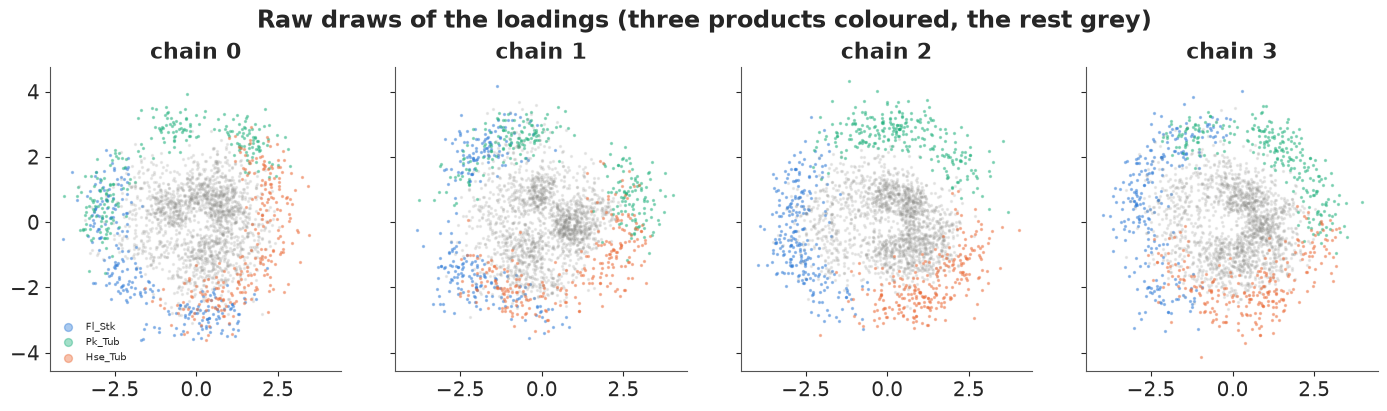

In [13]:
Lam_draws = idata_map2.posterior["Lambda"].to_numpy()          # (chain, draw, product, dim)
show = {"Fl_Stk": BLUE, "Hse_Tub": ORANGE, "Pk_Tub": AQUA}
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharex=True, sharey=True)
for c, ax in enumerate(axes):
    for j, p in enumerate(PRODUCTS):
        ax.scatter(*Lam_draws[c, ::4, j].T, s=2, alpha=0.4 if p in show else 0.15,
                   color=show.get(p, GREY), label=p if p in show and c == 0 else None)
    ax.set_title(f"chain {c}")
    ax.set_aspect("equal")
axes[0].legend(fontsize=7, markerscale=4, loc="lower left")
fig.suptitle("Raw draws of the loadings (three products coloured, the rest grey)");

Each product's draws stay at roughly the same distance from the origin, and the three coloured
products keep roughly the same angles to each other, but the configuration as a whole wanders
around the circle: draws are smeared along arcs within a chain, and chains disagree about where
on the circle the map sits. That is not a sampling failure. The likelihood depends on the loadings
only through $\boldsymbol{\lambda}_j^\top \mathbf{z}_h$, and for any rotation $R$,
$(\Lambda R)(R^\top \mathbf{z}_h) = \Lambda \mathbf{z}_h$, while the prior on $\mathbf{z}_h$ is
rotation-invariant. The posterior is a ring of equivalent maps. r_hat is right to complain that
the chains disagree about $\Lambda$ - $\Lambda$ is not identified - but everything we actually want
is:

* the **covariance** $\Lambda\Lambda^\top$ (how much the same households like two products) is
  invariant to $R$;
* so are the **choice probabilities**, **diversion ratios** and elasticities.

In [14]:
LLt = xr.DataArray(np.einsum("cdjk,cdik->cdji", Lam_draws, Lam_draws), dims=("chain", "draw", "j", "i"))
print(f"Lambda Lambda^T: r_hat max {float(az.rhat(LLt).max()):.3f}, "
      f"bulk ESS min {float(az.ess(LLt).min()):.0f}")

Lambda Lambda^T: r_hat max 1.034, bulk ESS min 155


The identified quantity has converged. Two standard ways out for the *map*: constrain $\Lambda$
(e.g. lower-triangular with a positive diagonal, which pins the first axis to one "anchor" product
and can create new multimodality if that anchor's true loading is near zero), or leave the
sampler alone and **align the draws afterwards**. We do the second: an orthogonal **Procrustes**
rotation of every draw onto a common reference (generalised Procrustes: align to one draw, average,
realign to the average, repeat). Rotations and reflections are allowed, stretching is not, so
relative distances and angles - the map's content - are untouched. Households' positions are
rotated by the same matrix.

In [15]:
def procrustes_align(L, iters=5):
    """Rotate (orthogonally) every draw of L (S, J, K) onto a common reference; returns L R, R."""
    ref = L[0]
    for _ in range(iters):
        U, _, Vt = np.linalg.svd(np.einsum("sjk,jl->skl", L, ref))
        R = U @ Vt
        ref = np.einsum("sjk,skl->jl", L, R) / len(L)
    # final orientation: principal axes of the mean map, Fleischmann's stick on the positive side
    _, _, Vt = np.linalg.svd(ref, full_matrices=False)
    flip = np.sign((ref @ Vt.T)[PRODUCTS.index("Fl_Stk")])
    R = R @ Vt.T * flip
    return np.einsum("sjk,skl->sjl", L, R), R


def aligned_map(idata):
    L = idata.posterior["Lambda"].to_numpy()
    C, S = L.shape[:2]
    L_al, R = procrustes_align(L.reshape(C * S, J, -1))
    z = idata.posterior["z"].to_numpy().reshape(C * S, H, -1)
    return L_al.reshape(C, S, J, -1), np.einsum("shk,skl->shl", z, R).reshape(C, S, H, -1)


Lam_al, z_al = aligned_map(idata_map2)
r_al = az.rhat(xr.DataArray(Lam_al, dims=("chain", "draw", "product", "dim")))
print(f"aligned loadings: r_hat {float(r_al.min()):.3f}-{float(r_al.max()):.3f}")

aligned loadings: r_hat 1.002-1.042


After alignment r_hat is at most about 1.04 - above the usual 1.01 threshold, but the same slow
mixing that the identified $\Lambda\Lambda^\top$ showed, not chains in different places. The map
can now be drawn with honest uncertainty: each product's loading with a 90% posterior ellipse, and the posterior mean position
of every household behind it.

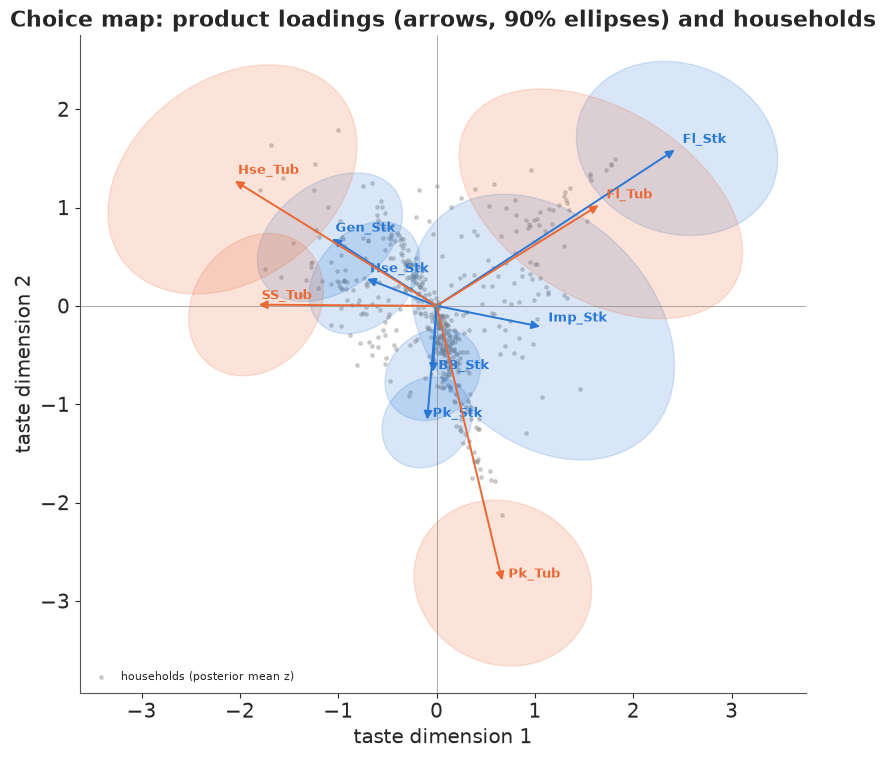

In [16]:
def draw_map(ax, L, z, title):
    Lf = L.reshape(-1, J, L.shape[-1])
    zm = z.reshape(-1, H, z.shape[-1]).mean(0)
    ax.scatter(*zm.T, s=6, color=GREY, alpha=0.35, label="households (posterior mean z)")
    for j, p in enumerate(PRODUCTS):
        m = Lf[:, j].mean(0)
        cov = np.cov(Lf[:, j].T)
        vals, vecs = np.linalg.eigh(cov)
        ang = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
        colr = BLUE if p.endswith("Stk") else ORANGE
        ax.add_patch(Ellipse(m, *(2 * np.sqrt(vals[::-1] * 4.6)), angle=ang, color=colr, alpha=0.18))
        ax.annotate("", m, (0, 0), arrowprops=dict(arrowstyle="-|>", color=colr, lw=1.4))
        ax.annotate(p, m, xytext=(4, 4), textcoords="offset points", fontsize=9, color=colr,
                    fontweight="bold")
    ax.axhline(0, color=GREY, lw=0.5)
    ax.axvline(0, color=GREY, lw=0.5)
    ax.set_aspect("equal")
    ax.set_xlabel("taste dimension 1")
    ax.set_ylabel("taste dimension 2")
    ax.set_title(title)


fig, ax = plt.subplots(figsize=(8, 7.5))
draw_map(ax, Lam_al, z_al, "Choice map: product loadings (arrows, 90% ellipses) and households")
ax.legend(loc="lower left", fontsize=8);

How to read it: a household at position $\mathbf{z}$ gets a utility bonus $\boldsymbol\lambda_j^\top
\mathbf{z}$ for product $j$ - large when it lies far out in the direction of $j$'s arrow. Products
whose arrows point the same way appeal to the same households and are close substitutes; products
pointing in opposite directions split the households between them. Long arrows are **polarising**
(strong likes and dislikes); short arrows, like Parkay and Blue Bonnet sticks, are products whose
appeal differs little between households, and their buyers are drawn from everywhere.

Three directions stand out, and they are neither "form" nor "brand":

* **Premium**: Fleischmann's stick and tub point the same way, with Imperial (short, uncertain)
  roughly along. Fleischmann's buyers are a distinct group that buys that *brand* in either form.
* **Value**: the house brand (stick and tub), the generic and Shedd's Spread point roughly the
  opposite way - households that buy on price.
* **Mainstream**: Parkay tub has a long arrow of its own, pointing roughly where the short Parkay
  and Blue Bonnet stick arrows point. Those two sticks sit near the centre: their buyers come from
  everywhere.

This is the quality-tier structure Allenby & Rossi (1991) described for these data.

---
# 5 · How many dimensions, and is loyalty real?

Fit one- and three-dimensional maps, a two-dimensional map without the idiosyncratic term
$\sigma e_{hj}$, and score them all on the held-out last purchases. For a map the prediction for a
household uses *its* posterior $\mathbf{z}_h$, $e_h$ and $\beta_h$, which is exactly what
"predict this household's next purchase" should mean.

In [17]:
def household_params(idata, thin=4):
    """Per-draw household intercepts A (S, H, J), price coefficients b (S, H), gamma (S,)."""
    p = idata.posterior.isel(draw=slice(None, None, thin))
    S = p.sizes["chain"] * p.sizes["draw"]
    alpha = np.concatenate([np.zeros((S, 1)), p["alpha"].to_numpy().reshape(S, -1)], axis=1)
    Lam = p["Lambda"].to_numpy().reshape(S, J, -1)
    A = alpha[:, None, :] + np.einsum("shk,sjk->shj", p["z"].to_numpy().reshape(S, H, -1), Lam)
    if "sigma" in p:
        A = A + p["sigma"].to_numpy().reshape(S)[:, None, None] * p["e"].to_numpy().reshape(S, H, J)
    b = -np.exp(p["mu_b"].to_numpy().reshape(S)[:, None]
                + p["sd_b"].to_numpy().reshape(S)[:, None] * p["u"].to_numpy().reshape(S, H))
    g = p["gamma"].to_numpy().reshape(S) if "gamma" in p else np.zeros(S)
    return A, b, g


def score_map(idata):
    A, b, g = household_params(idata)
    V = A[:, te["hh"]] + b[:, te["hh"], None] * te["X"] + g[:, None, None] * te["last"]
    return elpd_pointwise(V - special.logsumexp(V, -1, keepdims=True), te["y"])


idata_maps = {"map K=2": idata_map2}
for name, kw in [("map K=1", dict(K=1)), ("map K=3", dict(K=3)),
                 ("map K=2, no idiosyncratic", dict(K=2, idiosyncratic=False))]:
    idata_maps[name] = fit(choice_map(**kw), var_names=[v for v in KEEP if v not in ("sigma", "e")
                                                        or kw.get("idiosyncratic", True)])
scores |= {name: score_map(idata) for name, idata in idata_maps.items()}
gammas = {name: az.extract(idata, var_names="gamma").to_numpy() for name, idata in idata_maps.items()}
_s, _D, _ = diversion(*household_params(idata_maps["map K=3"], thin=10)[:2])
lift_k3 = np.nanmedian(_D / (_s[:, :, None] / (1 - _s[:, None, :])), 0)   # for section 7
for name in list(idata_maps):
    if name != "map K=2":
        del idata_maps[name]                       # keep memory down: only their gammas are needed now
print(score_table({k: v for k, v in scores.items() if k.startswith("map")}, base="map K=2"), "\n")
score_table(scores)

sampled in 18 s (400 warm-up steps, nutpie); divergences 0; max tree depth 5


sampled in 19 s (400 warm-up steps, nutpie); divergences 0; max tree depth 5


sampled in 17 s (400 warm-up steps, nutpie); divergences 0; max tree depth 5


                            elpd  diff  se_diff
model                                          
map K=2                   -391.1   0.0      0.0
map K=1                   -398.6  -7.5      2.8
map K=3                   -386.2   4.9      1.7
map K=2, no idiosyncratic -405.4 -14.4      5.7 



,elpd,diff,se_diff
model,,,
logit,-644.9,0.0,0.0
logit + last purchase,-561.2,83.7,17.2
nested: form,-639.6,5.3,1.7
nested: brand,-645.4,-0.5,0.2
nested: tier,-641.6,3.3,2.3
map K=2,-391.1,253.8,22.9
map K=1,-398.6,246.3,22.7
map K=3,-386.2,258.7,22.8
"map K=2, no idiosyncratic",-405.4,239.5,22.0


Modelling households is worth about **250 nats on 456 held-out purchases** - more than half a nat
per purchase, a 1.7-fold gain in the probability given to what the household actually bought.
Everything in section 3 was a rounding error by comparison.

Among the maps (first table, relative to K = 2): one dimension is worse by 7.5 $\pm$ 2.8, dropping
the idiosyncratic term costs 14 $\pm$ 6, and a **third dimension helps a little** - 4.9 $\pm$ 1.7
nats, about 0.01 nats per purchase. That is a real but small gain. We keep **K = 2 with the
idiosyncratic term** because the map can be drawn, and check in section 7 that the third dimension
does not change the substitution patterns we report.

## 5.1 · Loyalty is mostly heterogeneity

Now look at $\gamma$, the effect of the previous purchase, across models:

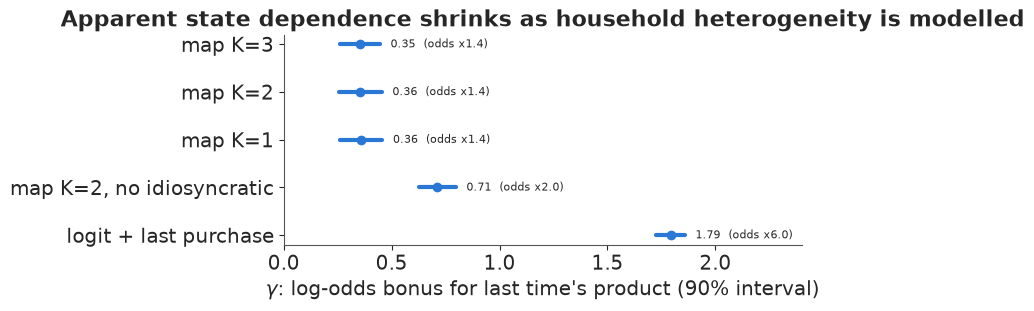

In [18]:
gam = {"logit + last purchase": az.extract(idata_logit_lag, var_names="gamma").to_numpy()}
gam |= {k: gammas[k] for k in ["map K=2, no idiosyncratic", "map K=1", "map K=2", "map K=3"]}
fig, ax = plt.subplots(figsize=(8, 3))
for i, (name, g) in enumerate(gam.items()):
    lo, mid, hi = np.quantile(g, [0.05, 0.5, 0.95])
    ax.plot([lo, hi], [i, i], color=BLUE, lw=3)
    ax.plot(mid, i, "o", color=BLUE)
    ax.text(hi + 0.05, i, f"{mid:.2f}  (odds x{np.exp(mid):.1f})", va="center", fontsize=8)
ax.set_yticks(range(len(gam)), list(gam))
ax.set_xlabel(r"$\gamma$: log-odds bonus for last time's product (90% interval)")
ax.set_xlim(0, 2.4)
ax.set_title("Apparent state dependence shrinks as household heterogeneity is modelled");

The pooled logit's "buying it last time multiplies the odds by 6" falls to 1.4 once
households have their own tastes. Most of the apparent loyalty was **spurious state dependence**
(Heckman 1981): households that bought Fleischmann's last time are Fleischmann's households, and
they would have bought it again anyway. An incomplete model of heterogeneity (no idiosyncratic
term) leaves some of it behind, which is how $\gamma$ is used in practice: as a diagnostic of
whether the heterogeneity model is rich enough. Keane (1997) and Dubé, Hitsch & Rossi (2010) found
the same pattern - genuine but modest state dependence - in other scanner panels.

For market structure this matters directly: a model that mistakes preference for habit will
predict that a price cut wins "loyal" customers for a long time, and will read the switching
matrix's blocks as dynamics rather than as who-competes-with-whom.

---
# 6 · Posterior predictive check: simulated purchase histories

Held-out scores judge one purchase per household. A market-structure model should also reproduce
the **patterns of switching**. For posterior draws, we re-run every household's purchase history:
start from its observed first purchase, and on each later trip draw the purchase from the model
given that trip's prices and the *simulated* previous purchase. Then compute the statistics of
section 1 on the simulated panel.

In [19]:
first = df[df["trip"] == 1].set_index("hh")["y"].reindex(range(H)).to_numpy()
T_max = df["trip"].max()
Xpad = np.zeros((H, T_max, J))
Xpad[df["hh"], df["trip"] - 1] = price
n_trips = df.groupby("hh").size().reindex(range(H)).to_numpy()


def simulate_panel(A, b, g, n_sims=100, seed=1):
    """Simulated histories (n_sims, H, T_max), -1 after a household's last trip."""
    r = np.random.default_rng(seed)
    idx = r.choice(len(b), n_sims, replace=False)
    Y = np.full((n_sims, H, T_max), -1)
    Y[:, :, 0] = first
    for t in range(1, T_max):
        V = A[idx] + b[idx][..., None] * Xpad[:, t] + g[idx, None, None] * np.eye(J)[Y[:, :, t - 1]]
        Pr = special.softmax(V, -1)
        draw = (Pr.cumsum(-1) > r.random(Pr.shape[:2])[..., None]).argmax(-1)
        Y[:, :, t] = np.where(t < n_trips, draw, -1)
    return Y


def panel_stats(Y):
    """Repeat rate, distinct products per household (share with 1, 2, 3+), switching lift."""
    prev, nxt = Y[:, :-1].ravel(), Y[:, 1:].ravel()
    ok = nxt >= 0
    sw = np.zeros((J, J))
    np.add.at(sw, (prev[ok], nxt[ok]), 1)
    counts = np.bincount(Y[Y >= 0], minlength=J)
    n_distinct = np.array([len(set(row[row >= 0])) for row in Y])
    return dict(repeat=np.trace(sw) / sw.sum(), lift=switching_lift(sw, counts / counts.sum()),
                distinct=np.array([(n_distinct == 1).mean(), (n_distinct == 2).mean(),
                                   (n_distinct >= 3).mean()]))


Y_obs = np.full((H, T_max), -1)
Y_obs[df["hh"], df["trip"] - 1] = df["y"]
obs_stats = panel_stats(Y_obs)
A_l, b_l = pooled_params(idata_logit_lag)
g_l = az.extract(idata_logit_lag, var_names="gamma").to_numpy()[::4]
sims = {"logit + last purchase": simulate_panel(np.repeat(A_l, H, 1), np.repeat(b_l, H, 1), g_l),
        "map K=2": simulate_panel(*household_params(idata_map2))}
sim_stats = {k: [panel_stats(Y) for Y in v] for k, v in sims.items()}
for k, st in sim_stats.items():
    print(f"{k:22s} repeat rate {q([s['repeat'] for s in st])} (observed {obs_stats['repeat']:.2f}); "
          f"households buying 1 / 2 / 3+ products: "
          f"{np.round(np.mean([s['distinct'] for s in st], 0), 2)} "
          f"(observed {np.round(obs_stats['distinct'], 2)})")

logit + last purchase  repeat rate [0.48 0.5  0.52] (observed 0.49); households buying 1 / 2 / 3+ products: [0.14 0.21 0.65] (observed [0.17 0.33 0.5 ])
map K=2                repeat rate [0.48 0.49 0.51] (observed 0.49); households buying 1 / 2 / 3+ products: [0.14 0.31 0.55] (observed [0.17 0.33 0.5 ])


''

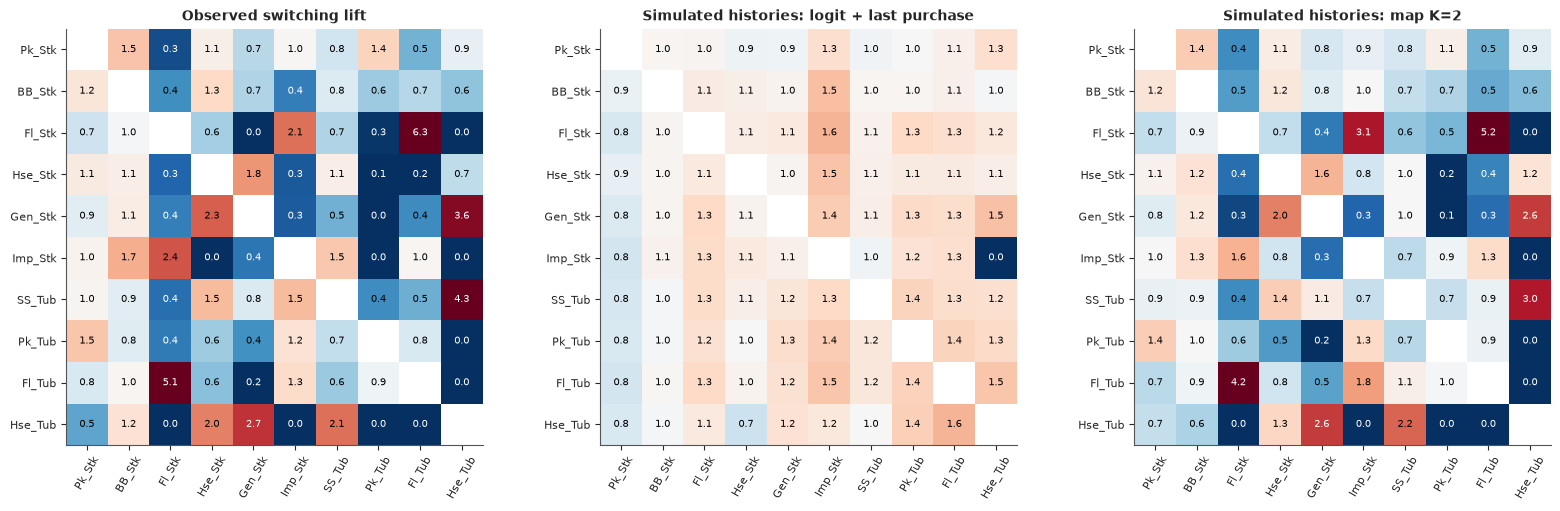

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
heat(axes[0], obs_stats["lift"], "Observed switching lift")
for ax, (k, st) in zip(axes[1:], sim_stats.items()):
    heat(ax, np.nanmedian([s["lift"] for s in st], 0), f"Simulated histories: {k}")
;

Both models get the overall **repeat rate** right (0.49), the pooled logit because that is what its
$\gamma$ was fitted to do. Everything else separates them:

* **Spread of households over products.** Observed: 17% of households bought one product, 33% two,
  50% three or more. The pooled logit gives 14 / 21 / 65% - it moves each household around the
  whole category. The map gives 14 / 31 / 55%, much closer though still slightly too promiscuous.
* **Switching lift.** The pooled logit's simulated lift is nearly flat (0.7-1.6, no blocks): every
  product exchanges buyers in proportion to its size. The map reproduces the blocks of the observed
  matrix - Fleischmann's stick and tub (5.2 and 4.2 simulated, 6.3 and 5.1 observed), the value
  group, Parkay stick with Blue Bonnet - even though it was fitted to individual choices, never to
  switching counts.

---
# 7 · Reading the market structure off the posterior

## 7.1 · Diversion lift

The counterpart of section 1's switching lift, now as a *counterfactual*: raise the price of $k$ a
little, holding everything else fixed; where do its lost purchases go, relative to the logit's
share-proportional answer? Computed per posterior draw from the households' parameters, with the
previous purchase switched off.

''

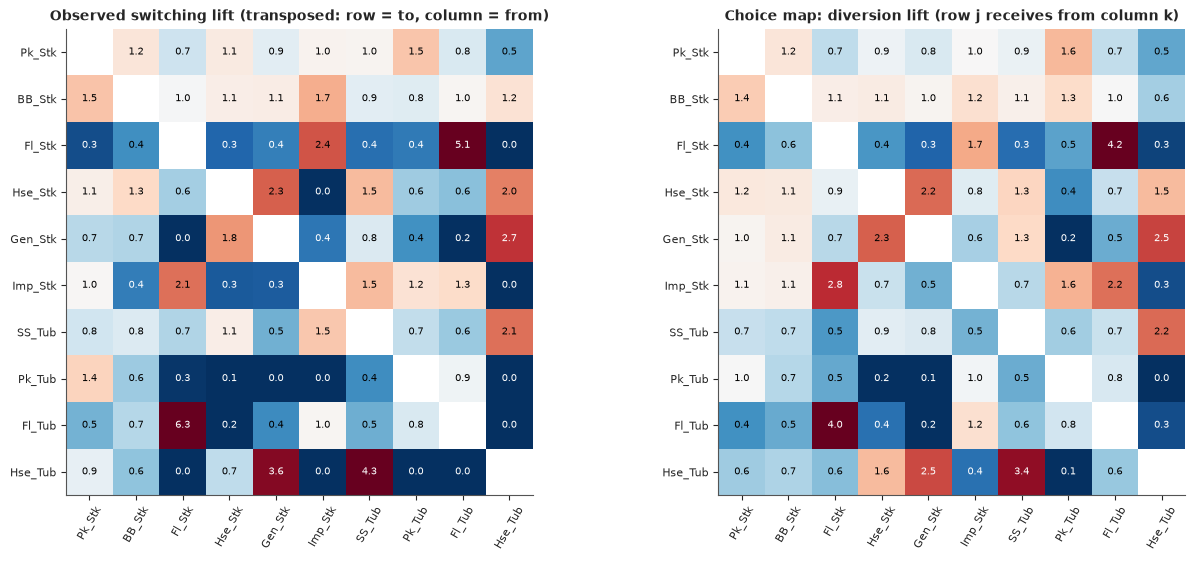

In [21]:
A2, b2, _ = household_params(idata_map2, thin=10)
s_map, D_map, el_map = diversion(A2, b2)
lift_map = D_map / (s_map[:, :, None] / (1 - s_map[:, None, :]))
lift_med = np.nanmedian(lift_map, 0)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
heat(axes[0], lift_raw.T, "Observed switching lift (transposed: row = to, column = from)")
heat(axes[1], lift_med, "Choice map: diversion lift (row j receives from column k)")
;

The model's diversion lift is a cleaned-up version of the switching lift: the same blocks, without
the zeros and extreme ratios of the smallest cells, and with each number now meaning something
definite (substitution after a price change, net of dynamics). The three-dimensional map (section
5) gives nearly the same matrix:

In [22]:
lk2, lk3 = np.log(lift_med), np.log(lift_k3)
ok = np.isfinite(lk2)
print(f"K=2 vs K=3 diversion lift: correlation of log lifts {np.corrcoef(lk2[ok], lk3[ok])[0, 1]:.2f}; "
      f"median |ratio - 1| {np.median(np.abs(np.exp(lk3[ok] - lk2[ok]) - 1)):.0%}")

K=2 vs K=3 diversion lift: correlation of log lifts 0.93; median |ratio - 1| 8%


How sure are we about the key pairs?

In [23]:
key_pairs = [("Fl_Stk", "Fl_Tub"), ("Fl_Tub", "Imp_Stk"), ("Hse_Stk", "Gen_Stk"), ("SS_Tub", "Hse_Tub"),
             ("Pk_Stk", "Pk_Tub"), ("Pk_Stk", "BB_Stk"), ("Pk_Stk", "SS_Tub"), ("Pk_Tub", "SS_Tub"),
             ("Fl_Stk", "Hse_Stk")]
rows = []
for k, j in key_pairs:
    ik, ij = PRODUCTS.index(k), PRODUCTS.index(j)
    x = lift_map[:, ij, ik]
    rows.append(dict(pair=f"{k} -> {j}", diversion=np.median(D_map[:, ij, ik]),
                     lift_5=np.quantile(x, 0.05), lift_50=np.median(x), lift_95=np.quantile(x, 0.95),
                     logit_diversion=np.median(D_logit[:, ij, ik])))
pd.DataFrame(rows).set_index("pair").round(2)

,diversion,lift_5,lift_50,lift_95,logit_diversion
pair,,,,,
Fl_Stk -> Fl_Tub,0.22,3.06,4.01,5.11,0.07
Fl_Tub -> Imp_Stk,0.05,1.08,2.15,3.29,0.03
Hse_Stk -> Gen_Stk,0.26,2.02,2.30,2.60,0.12
SS_Tub -> Hse_Tub,0.03,2.03,3.43,5.27,0.01
Pk_Stk -> Pk_Tub,0.08,0.87,1.00,1.18,0.08
Pk_Stk -> BB_Stk,0.29,1.32,1.43,1.53,0.19
Pk_Stk -> SS_Tub,0.09,0.61,0.72,0.84,0.10
Pk_Tub -> SS_Tub,0.05,0.31,0.62,1.08,0.07
Fl_Stk -> Hse_Stk,0.15,0.65,0.90,1.15,0.16


A small rise in the price of Fleischmann's stick sends 22% of its lost purchases to Fleischmann's
tub - four times the share-proportional rate (90% interval 3.1-5.1); the logit says 7%. The value
pairs (house stick to generic, Shedd's to house tub) are two to three times proportional. But
**Parkay stick to Parkay tub is exactly proportional** (lift 1.0, 0.87-1.18): Parkay buyers do not
prefer the other Parkay form, so Fleischmann's is the only brand whose buyers cross forms. And the
national-brand tubs lose *fewer* buyers to the cheap Shedd's tub than proportional (0.6). **Form is
not a submarket.**

## 7.2 · A market tree, with uncertainty

A tree is the traditional display. Cluster the products using $1/\text{lift}$ as a dissimilarity
(symmetrised; average linkage), per posterior draw, and record how often each group of products
appears as a cluster - a Bayesian version of bootstrap support on a phylogeny.

['Fl_Stk', 'Fl_Tub']: support 93%
['Hse_Tub', 'SS_Tub']: support 62%
['Gen_Stk', 'Hse_Stk']: support 64%
['Fl_Stk', 'Fl_Tub', 'Imp_Stk']: support 70%
['Gen_Stk', 'Hse_Stk', 'Hse_Tub', 'SS_Tub']: support 95%
['BB_Stk', 'Pk_Stk']: support 59%
['BB_Stk', 'Pk_Stk', 'Pk_Tub']: support 66%
['BB_Stk', 'Fl_Stk', 'Fl_Tub', 'Imp_Stk', 'Pk_Stk', 'Pk_Tub']: support 84%


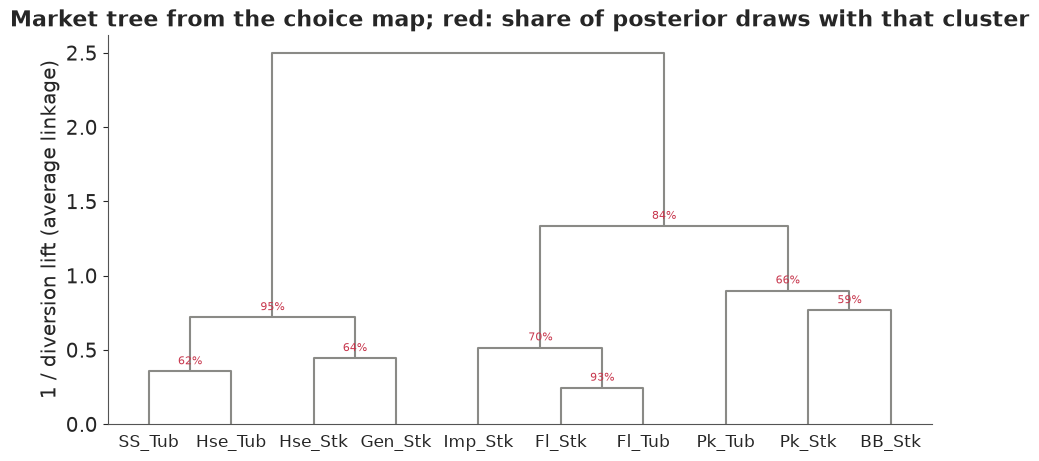

In [24]:
def tree(lift):
    L = np.nan_to_num((lift + lift.T) / 2, nan=np.inf)
    dist = 1 / L
    np.fill_diagonal(dist, 0)
    return hierarchy.linkage(dist[np.triu_indices(J, 1)], method="average")


def clusters(Z):
    """The clusters of a linkage, in merge order (row n of Z creates clusters(Z)[n])."""
    out, members = [], {i: frozenset([i]) for i in range(J)}
    for n, (a, b, *_) in enumerate(Z):
        members[J + n] = members[int(a)] | members[int(b)]
        out.append(members[J + n])
    return out


Z_med = tree(lift_med)
draw_sets = [set(clusters(tree(lift_map[s]))) for s in range(len(lift_map))]
support = [np.mean([c in d for d in draw_sets]) for c in clusters(Z_med)]
fig, ax = plt.subplots(figsize=(9, 4.5))
dn = hierarchy.dendrogram(Z_med, labels=PRODUCTS, ax=ax, color_threshold=0, above_threshold_color=GREY)
# each merge is drawn as an upside-down U at its height; label the top centre of each U
tops = [(d[1], (i[1] + i[2]) / 2) for i, d in zip(dn["icoord"], dn["dcoord"])]
for n, (c, sup) in enumerate(zip(clusters(Z_med), support)):
    if len(c) < J:
        x = [xc for h, xc in tops if np.isclose(h, Z_med[n, 2])][0]
        ax.text(x, Z_med[n, 2] + 0.03, f"{sup:.0%}", ha="center", va="bottom", fontsize=8, color=RED)
        print(f"{sorted(PRODUCTS[i] for i in c)}: support {sup:.0%}")
ax.set_ylabel("1 / diversion lift (average linkage)")
ax.set_title("Market tree from the choice map; red: share of posterior draws with that cluster");

The top split is **value versus the rest**: house stick and tub, generic and Shedd's form a branch
in 95% of posterior draws, and the six national-brand products the other branch in 84%. Within
the national brands, the **Fleischmann's pair is the most certain cluster of all (93%)**, with
Imperial joining it in 70% of draws; Parkay stick, Blue Bonnet and Parkay tub group together in
66%. The finer splits (which two value products pair first; Parkay stick with Blue Bonnet) are
close to coin tosses, and the tree says so. Grouping by *form* would need a branch for the four
tubs.

## 7.3 · Clout and vulnerability

Market structure is also asymmetric: a price cut by one product may steal a lot from another
without the reverse being true. Kamakura & Russell (1989) summarise this with two numbers per
product from the cross-price elasticities $\eta_{jk} = \frac{\partial s_j}{\partial p_k}
\frac{p_k}{s_j}$: **clout** $=\sum_{j \ne k} \eta_{jk}$ (how much $k$'s price moves everyone else)
and **vulnerability** $=\sum_{k \ne j} \eta_{jk}$ (how much $j$ is moved by everyone else's
prices).

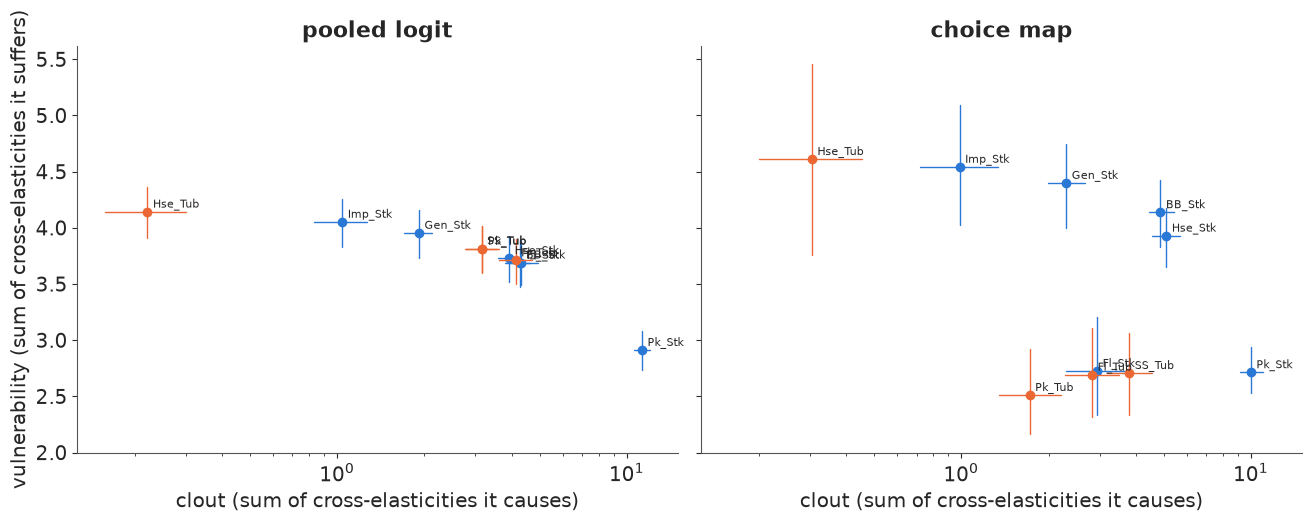

In [25]:
def clout_vulnerability(A, b, prices=p_med):
    Pr = special.softmax(A + b[..., None] * prices, axis=-1)
    s = Pr.mean(1)
    cross = -np.einsum("sh,shj,shk->sjk", b, Pr, Pr) / Pr.shape[1]
    eta = cross * prices[None, None, :] / s[:, :, None]
    idx = np.arange(J)
    eta[:, idx, idx] = 0
    return eta.sum(1), eta.sum(2)


fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, (name, (A, b)) in zip(axes, {"pooled logit": pooled_params(idata_logit),
                                    "choice map": (A2, b2)}.items()):
    clout, vuln = clout_vulnerability(A, b)
    for j, p in enumerate(PRODUCTS):
        colr = BLUE if p.endswith("Stk") else ORANGE
        cx, vy = np.quantile(clout[:, j], [0.05, 0.5, 0.95]), np.quantile(vuln[:, j], [0.05, 0.5, 0.95])
        ax.plot(cx[[0, 2]], [vy[1]] * 2, color=colr, lw=1)
        ax.plot([cx[1]] * 2, vy[[0, 2]], color=colr, lw=1)
        ax.plot(cx[1], vy[1], "o", color=colr)
        ax.annotate(p, (cx[1], vy[1]), xytext=(4, 3), textcoords="offset points", fontsize=8)
    ax.set_xscale("log")
    ax.set_xlabel("clout (sum of cross-elasticities it causes)")
    ax.set_title(name)
axes[0].set_ylabel("vulnerability (sum of cross-elasticities it suffers)");

In the pooled logit, vulnerability is nearly the same for every product (3.7-4.1, with the big
Parkay stick lower), because cross-elasticities depend only on the *other* product's share and
price. The choice map splits the products into two groups. **Low vulnerability**: Fleischmann's
stick and tub, Parkay tub, Shedd's Spread and Parkay stick - products with a clientele of their own
(long arrows on the map) or, for Parkay stick, buyers everywhere. **High vulnerability**: Blue
Bonnet, the house stick, the generic and Imperial, whose buyers also buy the products around them
and move when those are on promotion. Parkay stick has by far the most clout in both models. This
kind of asymmetry - who steals from whom on promotion - is what Allenby & Rossi (1991) studied in
these data.

---
# 8 · A merger screen

## 8.1 · Upward pricing pressure

Suppose brand A buys brand B. Before the merger, when A raised the price of its product $i$, the
buyers it lost to B's product $j$ were simply lost. After the merger, they are recaptured, and the
margin earned on them offsets the loss - so the merged firm has an incentive to raise $i$'s price.
The **gross upward pricing pressure index** (Farrell & Shapiro 2010; used in the 2010 US Horizontal
Merger Guidelines) measures that incentive as a fraction of $i$'s price:

$$\text{GUPPI}_i = \sum_{j \in B} D_{i \to j}\; m_j \,\frac{p_j}{p_i},$$

with $m_j$ the percentage margin on $j$. Competition authorities often treat a GUPPI below about 5%
as unlikely to cause concern. Everything hinges on the **diversion ratios**, which is why market
structure matters here: the logit says diversion follows size, the map says it follows the
submarkets.

Two honest caveats before computing anything. The data contain **only margarine purchases**, so a
household that stops buying margarine is invisible: every diversion ratio is *within the
category* and the ratios sum to one. Real diversion is smaller (some buyers switch to butter or
leave), so absolute GUPPIs here are upper bounds, and the **ranking** of mergers is the robust
output. And margins are not in the data: we assume 30% for every product and note how the answer
scales with that assumption (GUPPI is proportional to it).

We treat each national brand as a firm (Parkay owns its stick and tub, Fleischmann's likewise)
and screen every pair of the five national brands - hypothetical mergers, not a statement about
who owned what in the 1980s. The house brand and the generic belong to the retailer and are left
out. For a merger we report the largest GUPPI over the two firms' products.

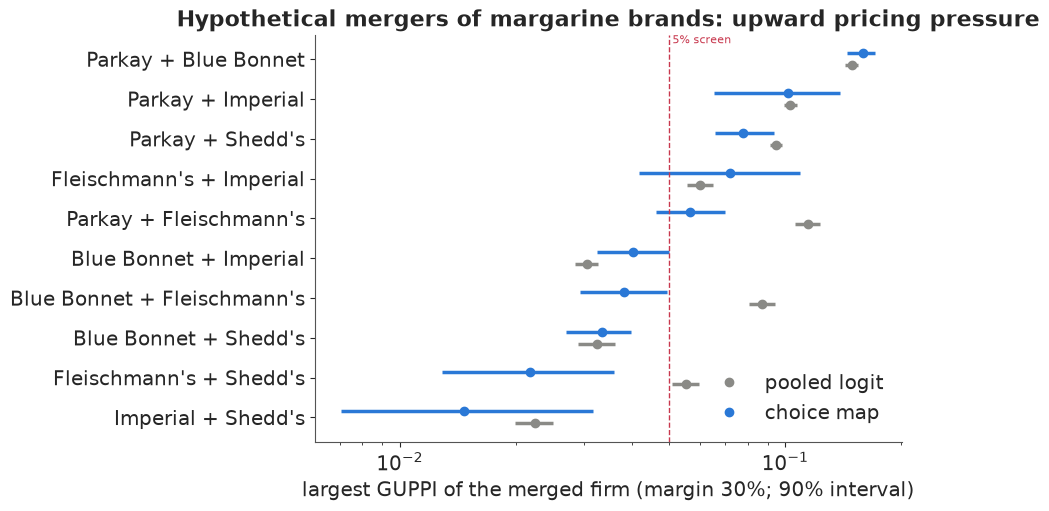

In [26]:
FIRMS = {"Parkay": ["Pk_Stk", "Pk_Tub"], "Blue Bonnet": ["BB_Stk"], "Fleischmann's": ["Fl_Stk", "Fl_Tub"],
         "Imperial": ["Imp_Stk"], "Shedd's": ["SS_Tub"]}
MARGIN = 0.30


def guppi(D, a, b):
    """Max GUPPI over products of firms a and b after they merge: (S,) draws."""
    out = []
    for f, g in [(a, b), (b, a)]:
        for i in FIRMS[f]:
            ii = PRODUCTS.index(i)
            out.append(sum(D[:, PRODUCTS.index(j), ii] * MARGIN * p_med[PRODUCTS.index(j)] / p_med[ii]
                           for j in FIRMS[g]))
    return np.max(out, axis=0)


firm_names = list(FIRMS)
mergers = [(a, b) for n, a in enumerate(firm_names) for b in firm_names[n + 1:]]
res = []
for a, b in mergers:
    for name, D in [("pooled logit", D_logit), ("choice map", D_map)]:
        g = guppi(D, a, b)
        res.append(dict(merger=f"{a} + {b}", model=name, lo=np.quantile(g, 0.05), med=np.median(g),
                        hi=np.quantile(g, 0.95), p_over_5=(g > 0.05).mean()))
res = pd.DataFrame(res)
order = res[res.model == "choice map"].sort_values("med")["merger"].tolist()

fig, ax = plt.subplots(figsize=(9, 5))
for k, (name, colr, off) in enumerate([("pooled logit", GREY, -0.15), ("choice map", BLUE, 0.15)]):
    r = res[res.model == name].set_index("merger").loc[order]
    y = np.arange(len(order)) + off
    ax.hlines(y, r["lo"], r["hi"], color=colr, lw=2.5)
    ax.plot(r["med"], y, "o", color=colr, label=name)
ax.axvline(0.05, color=RED, ls="--", lw=1)
ax.text(0.051, len(order) - 0.6, "5% screen", color=RED, fontsize=8)
ax.set_yticks(range(len(order)), order)
ax.set_xscale("log")
ax.set_xlabel(f"largest GUPPI of the merged firm (margin {MARGIN:.0%}; 90% interval)")
ax.set_title("Hypothetical mergers of margarine brands: upward pricing pressure")
ax.legend(loc="lower right");

In [27]:
tab = res.pivot(index="merger", columns="model", values=["med", "p_over_5"]).loc[order[::-1]]
tab.columns = [f"{m}: {'GUPPI median' if v == 'med' else 'P(GUPPI > 5%)'}" for v, m in tab.columns]
tab.round(3)

,choice map: GUPPI median,pooled logit: GUPPI median,choice map: P(GUPPI > 5%),pooled logit: P(GUPPI > 5%)
merger,,,,
Parkay + Blue Bonnet,0.159,0.149,1.000,1.000
Parkay + Imperial,0.102,0.103,0.998,1.000
Parkay + Shedd's,0.078,0.095,1.000,1.000
Fleischmann's + Imperial,0.072,0.060,0.878,1.000
Parkay + Fleischmann's,0.056,0.114,0.802,1.000
Blue Bonnet + Imperial,0.040,0.031,0.050,0.000
Blue Bonnet + Fleischmann's,0.038,0.087,0.040,1.000
Blue Bonnet + Shedd's,0.033,0.032,0.000,0.000
Fleischmann's + Shedd's,0.022,0.055,0.005,0.979


## 8.2 · What the screen says

The pooled logit flags **six** of the ten mergers, all with near-certainty, essentially by size:
anything with Parkay, plus Blue Bonnet + Fleischmann's and Fleischmann's + Shedd's. Its intervals
are narrow because it is confident about a substitution pattern it assumed.

The choice map changes the verdict where the structure says it should:

* **Fleischmann's with a brand in another tier is cleared.** Blue Bonnet + Fleischmann's falls from
  about 9% to 4% (P > 5% only 0.04), Fleischmann's + Shedd's from 5.5% to 2% (P = 0.005), and Parkay
  + Fleischmann's from 11% to 6% (P = 0.80). Fleischmann's buyers who face a price rise go to the
  other Fleischmann's product or to Imperial, not to the mainstream or value brands.
* **Fleischmann's + Imperial, the two premium brands, is the merger whose GUPPI goes *up*** (6% to
  7%, P = 0.88). It now ranks above Parkay + Fleischmann's, the opposite of the logit's order. Its
  interval is wide (Imperial has 74 purchases in the panel), and the screen says so.
* Parkay + Blue Bonnet stays the most worrying merger in both models: the two mainstream sticks
  are each other's closest substitutes *and* big.

A Bayesian screen reports the **probability** that a merger crosses the threshold, not just a point
estimate, and that is what a case team needs to decide which mergers deserve a closer look. The
absolute numbers are inflated by the missing outside good and scale with the assumed margin; the
re-ranking driven by the structure is the robust part.

---
## Summary

* **Market structure is substitution**: where the buyers of a product go when it gets dearer. The
  switching matrix hints at it but mixes heterogeneity, prices and state dependence, and its small
  cells are noisy. In the margarine panel it showed premium, value and mainstream blocks, not
  sticks vs tubs.
* **The pooled logit has no market structure by construction**: diversion is proportional to share
  (lift exactly 1), and elasticities are proportional to price, which made the expensive tubs the
  most price-sensitive products.
* **Nested-logit tests of competing hierarchies were nearly powerless**: form and tier nests both
  got $\lambda \approx 0.7$, but no nesting improved held-out purchases by more than about two
  standard errors, and pooled nesting cannot tell substitution from "bought by the same households".
* **A factor-structured hierarchical logit (a choice map)** improved held-out purchases by about 250
  nats. Its loadings had r_hat near 2 with no sampling problem at all - the map is identified only up
  to rotation - while $\Lambda\Lambda^\top$, probabilities and diversion ratios converged.
  Procrustes alignment of the draws gives a drawable map with honest uncertainty.
* **Apparent loyalty was mostly heterogeneity**: the last-purchase effect fell from odds x6 (pooled)
  to x1.4 once households had their own tastes.
* **Simulated purchase histories** reproduced the repeat rate and the blocks of the switching matrix,
  and came much closer to the spread of households over products; the pooled logit matched only the
  repeat rate.
* **The market is organised by tier, not form**: value (house, generic, Shedd's) versus national
  brands, and within those a Fleischmann's-plus-Imperial premium group. Fleischmann's is the only
  brand whose buyers cross forms; Parkay's do not.
* **Merger screen**: the share-driven logit flagged six of ten hypothetical mergers; the choice map
  cleared Fleischmann's mergers with other-tier brands and raised the premium-brand merger above
  Parkay + Fleischmann's. Within-category diversion and an assumed margin make absolute GUPPIs upper
  bounds; the re-ranking is the robust output.

## Try it yourself

1. **Demographics on the map.** `data.load("margarine_demos")` has income, family size, education
   and retirement for every household. Let $\mathbf{z}_h$'s mean depend on them
   ($\mathbf{z}_h \sim N(\Gamma \mathbf{w}_h, I)$) - which demographic moves households toward the
   premium arrows? Does it improve held-out purchases, or only explain the map?
2. **An outside good.** Diversion ratios here sum to one because non-purchase is unobserved. Add a
   "no purchase" option with an assumed trip-level purchase probability (say 1 in 4 trips includes
   margarine) and recompute the GUPPIs. How much do they shrink, and does the ranking survive?
3. **Ideal points instead of vectors.** Replace $\boldsymbol{\lambda}_j^\top \mathbf{z}_h$ by
   $-\lVert \mathbf{z}_h - \mathbf{x}_j \rVert^2$ (an ideal-point map: households like products near
   them). Is it identified up to rotation *and translation*? Does it predict held-out purchases
   better, and does the market tree change?